## Tutorial

https://www.kaggle.com/code/vitouphy/phoneme-recognition-with-wav2vec2

### DEMO DATA 

https://www.kaggle.com/datasets/mfekadu/darpa-timit-acousticphonetic-continuous-speech/

In [3]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version torch was built with:", torch.version.cuda)

Torch version: 2.10.0+cu126
CUDA available: True
CUDA version torch was built with: 12.6


## Creating .env file with this IDE

In [4]:
# # TESTING ROOTS
# import pandas as pd
# ROOT = os.path.join("..", "..", "..",)
# fpath = os.path.join(ROOT, "tst.csv")
# d = pd.DataFrame()
# d.to_csv(fpath)

In [5]:
# # Creating .env file

# import os

# env_content = """07_FR_phone_TokenType_READ=####### --- Token ----#######
# """
# #____________________________________________
# ROOT = os.path.join("..", "..", "..",)
# fpath = os.path.join(ROOT, ".env")
# with open(fpath, "w") as f:
#     f.write(env_content)

## Config HF Cache

In [6]:
import os

class cfg: 

    # to store HF pre-trained models weights and configs
    HF_CACHE_ROOT = os.path.join("..", "..", "..",
                                 "data",
                                 "05_cache", 
                                 "HF"
                                )



    # to store HF pre-trained models weights and configs
    HF_FINETUNE_ROOT = os.path.join("..", "..", "..",
                                    "data",
                                    "06_fine_tune",
                                    "01_tuto",
                                    "01_hug_llm",
                                    "ch03",
                                   )


    HF_FINETUNED_MODEL_SAVE_ROOT = os.path.join(HF_CACHE_ROOT,
                                                "FR_finetuned",
                                               )

## HF Cache management

https://huggingface.co/docs/datasets/en/cache

In [7]:
print("HF_HOME:", os.environ.get("HF_HOME"))
os.environ["HF_HOME"] = cfg.HF_CACHE_ROOT
print("HF_HOME:", os.environ.get("HF_HOME"))

HF_HOME: None
HF_HOME: ../../../data/05_cache/HF


In [8]:
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE"))
os.environ["HF_HUB_CACHE"] = cfg.HF_CACHE_ROOT
print("HF_HUB_CACHE:", os.environ.get("HF_HUB_CACHE"))

HF_HUB_CACHE: None
HF_HUB_CACHE: ../../../data/05_cache/HF


## Install libraries

In [9]:
# !pip install librosa==0.11.0
# !pip install matplotlib==3.10.8

## Import libraries

In [10]:
import io
import sys
import random
import json



#_________
import torch
import torchaudio

#__________
import librosa

#__________
# HF stack
import transformers
from transformers import pipeline

import datasets 
from datasets import load_dataset 
# from datasets import load_metric # deprecated, Now I'm using evaluate
from datasets import Audio as Audio_ds # the instances generated from load_dataset use under the hood Audio to decode (Audio use Torchcoced).

from datasets import Dataset

import evaluate

#_________
import numpy as np
import pandas as pd 

#_________
from dotenv import load_dotenv

#_________
from tqdm.auto import tqdm

#_________
import matplotlib
import matplotlib.pyplot as plt

from IPython.display import Audio
from IPython.display import display, HTML

In [11]:
transformers.__version__

'5.1.0'

In [12]:
torch.__version__

'2.10.0+cu126'

In [13]:
datasets.__version__

'4.5.0'

In [14]:
torch.cuda.is_available()

True

In [15]:
torch.cuda.device_count()

1

In [16]:
librosa.__version__

'0.11.0'

In [17]:
matplotlib.__version__

'3.10.8'

## Utilities

### safe_unzip()

In [18]:
import zipfile
import os

def safe_unzip(zip_path, extract_path=None):
    try:
        # Validate zip file exists
        if not os.path.exists(zip_path):
            raise FileNotFoundError(f"Zip file not found: {zip_path}")
        
        # Set extract path
        if extract_path is None:
            extract_path = os.path.splitext(zip_path)[0]
        
        # Create directory if needed
        os.makedirs(extract_path, exist_ok=True)
        
        # Extract
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            # Test if zip is valid
            bad_file = zip_ref.testzip()
            if bad_file:
                raise zipfile.BadZipFile(f"Corrupted file in zip: {bad_file}")
            
            zip_ref.extractall(extract_path)
            print(f"Successfully extracted to: {extract_path}")
            
    except FileNotFoundError as e:
        print(f"Error: {e}")
    except zipfile.BadZipFile as e:
        print(f"Error: Invalid or corrupted zip file - {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

## Service Token Authentication

In [19]:
# Verify token is loaded
load_dotenv()

HF_TOKEN_READ = os.getenv("07_FR_phone_TokenType_READ")
print(f"Token loaded: {'Yes' if HF_TOKEN_READ else 'No'}")

Token loaded: Yes


## Unzip dataset

In [20]:
TIMIT_KAGGLE_ROOT = os.path.join("..", "..", "..",
                                 'data', 
                                 '06_timit_kaggle',
                                ) 

zip_fname = 'timit_kaggle.zip'

# zip_fpath = os.path.join(TIMIT_KAGGLE_ROOT, zip_fname)
# zip_extract_path = TIMIT_KAGGLE_ROOT

# safe_unzip(zip_path=zip_fpath, extract_path=zip_extract_path)
# print(f"zip file has been extrated in this folder: \n {zip_extract_path}")

## Paths

In [21]:
TIMIT_KAGGLE_ROOT = os.path.join("..", "..", "..",
                                 'data', 
                                 '06_timit_kaggle',
                                )
#=========================================================
data_path = os.path.join(TIMIT_KAGGLE_ROOT, 'data') 


## Load metadata

In [22]:
df_train = pd.read_csv(os.path.join(TIMIT_KAGGLE_ROOT, 'train_data.csv'))
df_train

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TRAIN,DR4,MMDM0,SI681.WAV.wav,TRAIN/DR4/MMDM0/SI681.WAV.wav,TRAIN\\DR4\\MMDM0\\SI681.WAV.wav,True,True,False,False,False
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
31673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_test = pd.read_csv(os.path.join(TIMIT_KAGGLE_ROOT, 'test_data.csv'))
df_test

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TEST,DR4,MGMM0,SX139.WAV,TEST/DR4/MGMM0/SX139.WAV,TEST\\DR4\\MGMM0\\SX139.WAV,False,True,False,False,False
1,2.0,TEST,DR4,MGMM0,SX139.WAV.wav,TEST/DR4/MGMM0/SX139.WAV.wav,TEST\\DR4\\MGMM0\\SX139.WAV.wav,True,True,False,False,False
2,3.0,TEST,DR4,MGMM0,SX139.TXT,TEST/DR4/MGMM0/SX139.TXT,TEST\\DR4\\MGMM0\\SX139.TXT,False,False,False,False,True
3,4.0,TEST,DR4,MGMM0,SI499.WRD,TEST/DR4/MGMM0/SI499.WRD,TEST\\DR4\\MGMM0\\SI499.WRD,False,False,True,False,False
4,5.0,TEST,DR4,MGMM0,SX319.WRD,TEST/DR4/MGMM0/SX319.WRD,TEST\\DR4\\MGMM0\\SX319.WRD,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
31673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
df = pd.concat([df_train, df_test])
df

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,1.0,TRAIN,DR4,MMDM0,SI681.WAV.wav,TRAIN/DR4/MMDM0/SI681.WAV.wav,TRAIN\\DR4\\MMDM0\\SI681.WAV.wav,True,True,False,False,False
1,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
2,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
3,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
4,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
31673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31674,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
c1 = df['is_converted_audio'] == False
df = df[c1].reset_index(drop=True)
df

,index,test_or_train,dialect_region,speaker_id,filename,path_from_data_dir,path_from_data_dir_windows,is_converted_audio,is_audio,is_word_file,is_phonetic_file,is_sentence_file
0,2.0,TRAIN,DR4,MMDM0,SI1311.PHN,TRAIN/DR4/MMDM0/SI1311.PHN,TRAIN\\DR4\\MMDM0\\SI1311.PHN,False,False,False,True,False
1,3.0,TRAIN,DR4,MMDM0,SI1311.WRD,TRAIN/DR4/MMDM0/SI1311.WRD,TRAIN\\DR4\\MMDM0\\SI1311.WRD,False,False,True,False,False
2,4.0,TRAIN,DR4,MMDM0,SX321.PHN,TRAIN/DR4/MMDM0/SX321.PHN,TRAIN\\DR4\\MMDM0\\SX321.PHN,False,False,False,True,False
3,5.0,TRAIN,DR4,MMDM0,SX321.WRD,TRAIN/DR4/MMDM0/SX321.WRD,TRAIN\\DR4\\MMDM0\\SX321.WRD,False,False,True,False,False
4,6.0,TRAIN,DR4,MMDM0,SI681.TXT,TRAIN/DR4/MMDM0/SI681.TXT,TRAIN\\DR4\\MMDM0\\SI681.TXT,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
25195,8395.0,TEST,DR8,MPAM0,SX19.WAV,TEST/DR8/MPAM0/SX19.WAV,TEST\\DR8\\MPAM0\\SX19.WAV,False,True,False,False,False
25196,8396.0,TEST,DR8,MPAM0,SX109.TXT,TEST/DR8/MPAM0/SX109.TXT,TEST\\DR8\\MPAM0\\SX109.TXT,False,False,False,False,True
25197,8398.0,TEST,DR8,MPAM0,SX289.WRD,TEST/DR8/MPAM0/SX289.WRD,TEST\\DR8\\MPAM0\\SX289.WRD,False,False,True,False,False
25198,8399.0,TEST,DR8,MPAM0,SX109.WAV,TEST/DR8/MPAM0/SX109.WAV,TEST\\DR8\\MPAM0\\SX109.WAV,False,True,False,False,False


## Merging files for same subID

timit dataset come with in files, not organize in train test, this will help to process the data when I pay for it

In [26]:
%%time
data = {}

for idx, row in tqdm(df.iterrows()):

    # meta file with linux sys path sep to audio file. 
    #  Each audio file name is related to subID
    #  the root folder that a "data" folder with all wav file, phonetic, word files. 
    path = row['path_from_data_dir'] 

    # Extracting from path of wav the subId path. 
    entry_id = path.split('.')[0]

    #__________________________________
    # Creating empty dictionary to story subID info.
    if entry_id not in data:
        data[entry_id] = {}

    #__________________________________
    # data_path is the root in the system to "data" folder in TIMIT kaggle root folder.
    if row['is_audio'] is True:
        data[entry_id]['audio_file'] = os.path.join(data_path, path)

    elif row['is_word_file'] is True:
        data[entry_id]['word_file'] = os.path.join(data_path, path)

    elif row['is_phonetic_file'] is True:
        data[entry_id]['phonetic_file'] = os.path.join(data_path, path)


    #__________________________________
    
    # break

0it [00:00, ?it/s]

CPU times: user 952 ms, sys: 6.39 ms, total: 959 ms
Wall time: 958 ms


In [27]:
len(data.keys()) # there are 6300 entryID which I think is subID, at this point I dont know if each subID has all three docs, .wav, .phn and .wrd 

6300

### Extracting subID with 3 files

In [28]:
keys = [key for key in data.keys() if len(data[key]) == 3]
len(keys)

3360

** it seems that out of the 6300, only 3360 has the three files 

## Split data into train,val,test

In [29]:
random.Random(101).shuffle(keys)

num_train = int(len(keys) * 0.8)
num_valid = int(len(keys) * 0.1)
num_test = len(keys) - num_train - num_valid

train_keys = keys[:num_train]
valid_keys = keys[num_train:num_train + num_valid]
test_keys = keys[-num_test:]

In [30]:
print(f"train_keys {len(train_keys )}")
print(f"valid_keys {len(valid_keys )}")
print(f"test_keys {len(test_keys )}")

train_keys 2688
valid_keys 336
test_keys 336


In [31]:
# form the data dictionary and with the keys split into train, val and test, organize data for each set 
train = { key:data[key] for key in train_keys }
valid = { key:data[key] for key in valid_keys }
test  = { key:data[key] for key in test_keys }

## How many hours each set

### get_durations()

In [32]:
def get_durations(dict_data):

    """
    Parameters: 
    ----------
        dict_data: dict_data is the train, val, test or global data with subid and 
                    each subject id has a dictionary with 3 keys to point to 
                    .wav, .phn, or .wrd. 
                

    """
    
    total_durations = 0

    for entry in dict_data.values():
        audio_data, _ = librosa.load(entry['audio_file'], sr=16_000)
        duration = len(audio_data) / 16_000 # seconds
        total_durations += duration

    return int(total_durations)

In [33]:
%%time
print(f"Duration of Train: {get_durations(train) // 60} minutes")
print(f"Duration of Valid: {get_durations(valid) // 60} minutes")
print(f"Duration of Test : {get_durations(test) // 60} minutes\n")

Duration of Train: 137 minutes
Duration of Valid: 17 minutes
Duration of Test : 17 minutes

CPU times: user 14.5 s, sys: 5.09 s, total: 19.5 s
Wall time: 45.6 s


## SAVE the dictionary as json files 

I create a dictionary for each subID with the file path pointers for .wav, .phn and .wrd, I will store them for fine-tuning 

In [34]:
custom_split_data_path = os.path.join(TIMIT_KAGGLE_ROOT, "01_custom_split_meta")

os.makedirs(custom_split_data_path, exist_ok=True)
custom_split_data_path

'../../../data/06_timit_kaggle/01_custom_split_meta'

In [35]:
fname = 'custom_train.json'
fpath = os.path.join(custom_split_data_path,fname )
with open(fpath, "w") as f:
    json.dump(train, f)

In [36]:
fname = 'custom_valid.json'
fpath = os.path.join(custom_split_data_path,fname )
with open(fpath, "w") as f:
    json.dump(valid, f)

In [37]:
fname = 'custom_test.json'
fpath = os.path.join(custom_split_data_path,fname )
with open(fpath, "w") as f:
    json.dump(test, f)

## Conver to HF dataformat

### Proto

In [38]:
for key, value in train.items(): 

    break

In [39]:
value

{'audio_file': '../../../data/06_timit_kaggle/data/TEST/DR7/FISB0/SA1.WAV',
 'phonetic_file': '../../../data/06_timit_kaggle/data/TEST/DR7/FISB0/SA1.PHN',
 'word_file': '../../../data/06_timit_kaggle/data/TEST/DR7/FISB0/SA1.WRD'}

In [40]:
value['audio_file']

'../../../data/06_timit_kaggle/data/TEST/DR7/FISB0/SA1.WAV'

In [41]:
key

'TEST/DR7/FISB0/SA1'

### convert_to_feature_dict()

In [42]:
def convert_to_feature_dict(data_dict):
    # convert each feature into a list instead
    audio_files = []
    word_files = []
    phonetic_files = []
    for key, value in data_dict.items():
        audio_files.append(value['audio_file'])
        word_files.append(value['word_file'])
        phonetic_files.append(value['phonetic_file'])
    
    return {
        'audio_file': audio_files,
        'word_file': word_files,
        'phonetic_file': phonetic_files
    }

In [43]:
'''
Previously dictonary train, valid and test has this structure 
    trian = {'subId_01': {'audio_file': path_str, 'word_file': path_str, 'phonetic_file': path_str}, 
             'subId_02': {'audio_file': path_str, 'word_file': path_str, 'phonetic_file': path_str}, 
             ...
             }

    with conver_to_feature_dict() the subID will be remove, this is to be in the HF dataset style. 
    trian = { 'audio_file': list with all path of audio file, 
              'word_file': list with all path of .wrd files, 
              'phonetic_file': list with all path of .phn files, 
            }
        now, subID does not appear, but same idx in these three list refer to the same sID. 

'''



train = convert_to_feature_dict(train)
valid = convert_to_feature_dict(valid)
test  = convert_to_feature_dict(test)

In [44]:
train.keys()

dict_keys(['audio_file', 'word_file', 'phonetic_file'])

### transform to dataset HF style

In [45]:
train_dataset = Dataset.from_dict(train)
valid_dataset = Dataset.from_dict(valid)
test_dataset = Dataset.from_dict(test)

In [46]:
train_dataset

Dataset({
    features: ['audio_file', 'word_file', 'phonetic_file'],
    num_rows: 2688
})

## Read files for phonetics

### read_text_file()

In [47]:
def read_text_file(filepath):

    '''
    Description
    -----------

        =================
        Phonetic info
        this is the structure of a .phn file 
            0 3050 h#
            3050 4559 sh
            4559 5723 ix
            5723 6642 hv
            6642 8772 eh
            8772 9190 dcl
            9190 10337 jh

            as you can see it is seperator by space, it looks like time points (for sr=16000)
                and the last [-1] column is the one with the Arphable phonetic symbole. 


        =================
        word info
        similar happens with .wrd file 
            3050 5723 she
            5723 10337 had
            9190 11517 your
            11517 16334 dark
            16334 21199 suit
            21199 22560 in
            22560 28064 greasy
            28064 33360 wash
            33754 37556 water
            37556 40313 all
            40313 44586 year
        as you can see it is seperator by space, it looks like time points (for sr=16000)
            and the last [-1] column per line is the one that contains the word. 
    
    '''

    
    with open(filepath) as f:
        tokens = [line.split()[-1] for line in f]
        return " ".join(tokens)

In [48]:
item_path = test_dataset['phonetic_file'][0]
item_path

'../../../data/06_timit_kaggle/data/TRAIN/DR3/MBEF0/SI1911.PHN'

In [49]:
read_text_file(filepath=item_path)

'h# t eh n y ih r z ix gcl g ow dh ey bcl b l uw ah pcl p s ah m ah v aa r dcl d ih tcl ch ix s h#'

### prepare_text_data() 

In [50]:
def prepare_text_data(item):

    """
    Description:
    ------------
        for mapping the dataset object. 
            HF Dataset object hast the method .map() which will loop for each item in the feature list value. 

    """
    
    item['text'] = read_text_file(item['word_file'])
    item['phonetic'] = read_text_file(item['phonetic_file'])
    return item

### Mapping Dataset object HF

In [51]:
train_dataset

Dataset({
    features: ['audio_file', 'word_file', 'phonetic_file'],
    num_rows: 2688
})

In [52]:
train_dataset = (train_dataset
                 .map(prepare_text_data)
                 .remove_columns(["word_file", "phonetic_file"]))
train_dataset 

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

Dataset({
    features: ['audio_file', 'text', 'phonetic'],
    num_rows: 2688
})

In [53]:
valid_dataset = (valid_dataset
                 .map(prepare_text_data)
                 .remove_columns(["word_file", "phonetic_file"]))
valid_dataset

Map:   0%|          | 0/336 [00:00<?, ? examples/s]

Dataset({
    features: ['audio_file', 'text', 'phonetic'],
    num_rows: 336
})

In [54]:
test_dataset  = (test_dataset
                 .map(prepare_text_data)
                 .remove_columns(["word_file", "phonetic_file"]))
test_dataset

Map:   0%|          | 0/336 [00:00<?, ? examples/s]

Dataset({
    features: ['audio_file', 'text', 'phonetic'],
    num_rows: 336
})

## Standarize Phonetics 

In [55]:
train_dataset['phonetic'][0]

'h# sh iy hv ae dcl d y er dcl d aa r kcl k s ux tcl ih n gcl g r iy z iy w ao sh epi w ao dx er q ao l y ih axr h#'

In [56]:
train_phonetics = [phone for x in train_dataset for phone in x['phonetic'].split()]
train_phonetics.sort()
len(train_phonetics) 

102744

In [57]:
print(set(train_phonetics))

{'g', 'uw', 'pcl', 'dh', 'em', 'ey', 'hh', 'w', 'z', 'pau', 'uh', 'dx', 'th', 'ae', 'm', 'aa', 'v', 'ay', 'd', 'y', 'tcl', 'en', 'jh', 'axr', 'sh', 'b', 'ow', 'ax', 'epi', 'h#', 'n', 'eh', 'f', 'aw', 'p', 'eng', 'gcl', 'hv', 'ax-h', 'oy', 'ch', 'ah', 's', 'er', 'k', 'el', 'ng', 'nx', 'iy', 'ix', 'r', 'ux', 'bcl', 't', 'zh', 'ao', 'ih', 'q', 'dcl', 'kcl', 'l'}


In [58]:
len(set(train_phonetics))

61

**Timit has 61 phonetic sounds**
- Each dataset has different phonetics system

In [59]:
# TimitBet 61 phoneme mapping to 39 phonemes
# by Lee, K.-F., & Hon, H.-W. (1989). Speaker-independent phone 
# recognition using hidden Markov models. IEEE Transactions on Acoustics, 
# Speech, and Signal Processing, 37(11), 1641–1648. doi:10.1109/29.46546 
'''
'q' is a glottal stop 

'''

phon61_map39 = {
    'iy':'iy',  'ih':'ih',   'eh':'eh',  'ae':'ae',    'ix':'ih',  'ax':'ah',   'ah':'ah',  'uw':'uw',
    'ux':'uw',  'uh':'uh',   'ao':'aa',  'aa':'aa',    'ey':'ey',  'ay':'ay',   'oy':'oy',  'aw':'aw',
    'ow':'ow',  'l':'l',     'el':'l',  'r':'r',      'y':'y',    'w':'w',     'er':'er',  'axr':'er',
    'm':'m',    'em':'m',     'n':'n',    'nx':'n',     'en':'n',  'ng':'ng',   'eng':'ng', 'ch':'ch',
    'jh':'jh',  'dh':'dh',   'b':'b',    'd':'d',      'dx':'dx',  'g':'g',     'p':'p',    't':'t',
    'k':'k',    'z':'z',     'zh':'sh',  'v':'v',      'f':'f',    'th':'th',   's':'s',    'sh':'sh',
    'hh':'hh',  'hv':'hh',   'pcl':'h#', 'tcl':'h#', 'kcl':'h#', 'qcl':'h#','bcl':'h#','dcl':'h#',
    'gcl':'h#','h#':'h#',  '#h':'h#',  'pau':'h#', 'epi': 'h#','nx':'n',   'ax-h':'ah','q':'q' 
}

In [60]:
# phon61_map39

### convert_phon61_to_phon39()

In [61]:
def convert_phon61_to_phon39(sentence):
    tokens = [phon61_map39[x] for x in sentence.split()]
    return " ".join(tokens)


### normalize_phones()

In [62]:
def normalize_phones(item):
    item['phonetic'] = convert_phon61_to_phon39(item['phonetic'])
    return item

### maping reduce dict phone

In [63]:
train_dataset = train_dataset.map(normalize_phones)
valid_dataset = valid_dataset.map(normalize_phones)
test_dataset = test_dataset.map(normalize_phones)

Map:   0%|          | 0/2688 [00:00<?, ? examples/s]

Map:   0%|          | 0/336 [00:00<?, ? examples/s]

Map:   0%|          | 0/336 [00:00<?, ? examples/s]

In [64]:
train_phonetics = [phone for x in train_dataset for phone in x['phonetic'].split()]
valid_phonetics = [phone for x in valid_dataset for phone in x['phonetic'].split()]
test_phonetics = [phone for x in test_dataset for phone in x['phonetic'].split()]

print("num of train phones:\t", len(set(train_phonetics)))
print("num of valid phones:\t", len(set(valid_phonetics)))
print("num of test phones:\t", len(set(test_phonetics)))

num of train phones:	 40
num of valid phones:	 40
num of test phones:	 40


## VIZ phonetic distribution

In [65]:
phone_vocabs = set(train_phonetics)
phone_vocabs.remove('h#')
phone_vocabs = sorted(phone_vocabs)
print(phone_vocabs, len(phone_vocabs))

['aa', 'ae', 'ah', 'aw', 'ay', 'b', 'ch', 'd', 'dh', 'dx', 'eh', 'er', 'ey', 'f', 'g', 'hh', 'ih', 'iy', 'jh', 'k', 'l', 'm', 'n', 'ng', 'ow', 'oy', 'p', 'q', 'r', 's', 'sh', 't', 'th', 'uh', 'uw', 'v', 'w', 'y', 'z'] 39


### count_frequency()

In [66]:
def count_frequency(phonetics):
    phone_counts = {phone: 0 for phone in phone_vocabs}
    for phone in phonetics:
        if phone in phone_vocabs:
            phone_counts[phone] += 1
    # eliminate h# for visualization purposes
    return [phone_counts[phone] for phone in phone_vocabs] 

In [67]:
train_phone_counts = count_frequency(train_phonetics)
valid_phone_counts = count_frequency(valid_phonetics)
test_phone_counts  = count_frequency(test_phonetics)

In [68]:
train_phone_ratio = [count / sum(train_phone_counts) for count in train_phone_counts]
valid_phone_ratio = [count / sum(valid_phone_counts) for count in valid_phone_counts]
test_phone_ratio  = [count / sum(test_phone_counts) for count in test_phone_counts]

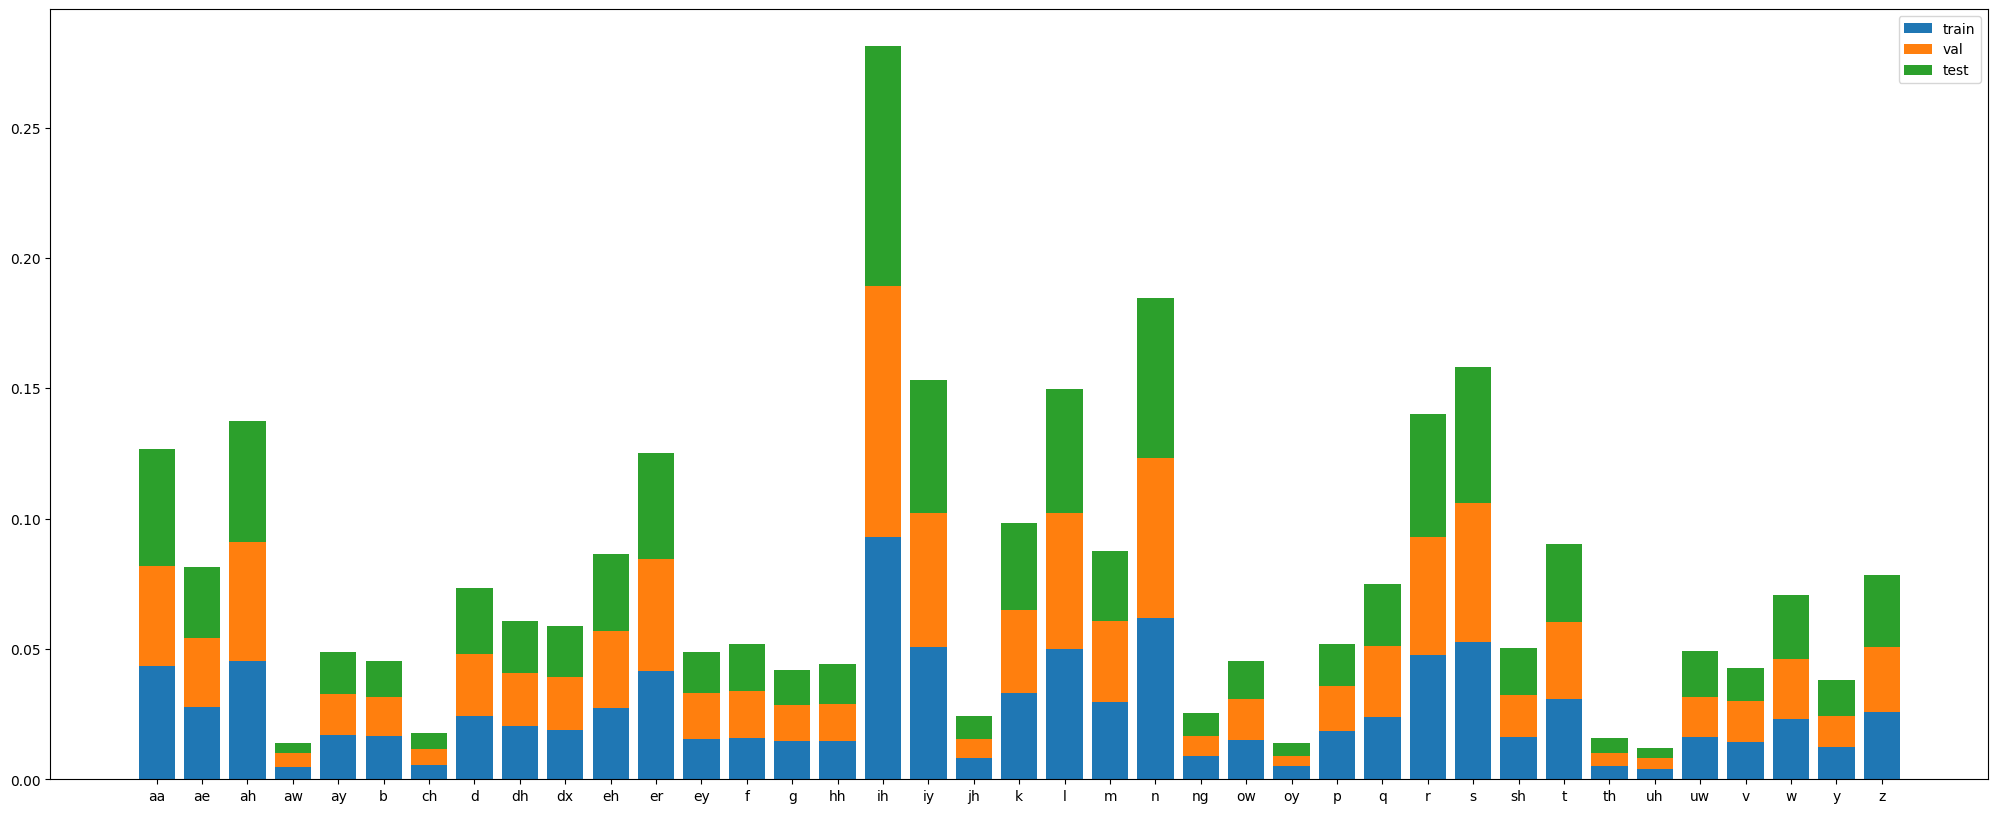

In [69]:
plt.figure(figsize=(25,10))

plt.bar(phone_vocabs, train_phone_ratio, label='train')
plt.bar(phone_vocabs, valid_phone_ratio, bottom=train_phone_ratio, label='val')
plt.bar(phone_vocabs, test_phone_ratio, bottom=[(x+y) for x,y in zip(train_phone_ratio, valid_phone_ratio)], label='test')

plt.legend()
plt.show()

## load audio

In [70]:
train_dataset

Dataset({
    features: ['audio_file', 'text', 'phonetic'],
    num_rows: 2688
})

In [71]:
train_dataset = (train_dataset
                 .cast_column("audio_file", Audio_ds(sampling_rate=16_000))
                 .rename_column('audio_file', 'audio'))
valid_dataset = (valid_dataset
                 .cast_column("audio_file", Audio_ds(sampling_rate=16_000))
                 .rename_column('audio_file', 'audio'))
test_dataset = (test_dataset
                 .cast_column("audio_file", Audio_ds(sampling_rate=16_000))
                 .rename_column('audio_file', 'audio'))

In [72]:
train_dataset

Dataset({
    features: ['audio', 'text', 'phonetic'],
    num_rows: 2688
})

In [73]:
train_dataset[0]


{'audio': <datasets.features._torchcodec.AudioDecoder at 0x7f3cf8431960>,
 'text': 'she had your dark suit in greasy wash water all year',
 'phonetic': 'h# sh iy hh ae h# d y er h# d aa r h# k s uw h# ih n h# g r iy z iy w aa sh h# w aa dx er q aa l y ih er h#'}

In [74]:
train_dataset['audio'][0]['array']

array([-6.1035156e-05,  6.1035156e-05,  1.2207031e-04, ...,
        9.1552734e-05,  3.6621094e-04, -3.0517578e-04],
      shape=(79770,), dtype=float32)

In [75]:
train_dataset['audio'][0]['sampling_rate']

16000

In [76]:
# train_dataset['audio'][0]['path']

In [77]:
rand_int = 0


print("Text:", train_dataset[rand_int]["text"])
print("Phonetics:", train_dataset[rand_int]["phonetic"])
print("Input array shape:", train_dataset[rand_int]["audio"]["array"].shape)
print("Sampling rate:", train_dataset[rand_int]["audio"]["sampling_rate"])
Audio(data=train_dataset[rand_int]["audio"]["array"], autoplay=False, rate=16000)

Text: she had your dark suit in greasy wash water all year
Phonetics: h# sh iy hh ae h# d y er h# d aa r h# k s uw h# ih n h# g r iy z iy w aa sh h# w aa dx er q aa l y ih er h#
Input array shape: (79770,)
Sampling rate: 16000


## Build vocab

In [78]:
vocab_train = list(set(train_phonetics)) + [' ']
vocab_valid = list(set(valid_phonetics)) + [' ']
vocab_test  = list(set(test_phonetics)) + [' ']

In [79]:
vocab_list = list(set(vocab_train + vocab_valid + vocab_test))
vocab_dict = {v: k for k, v in enumerate(sorted(vocab_list))}

print(vocab_dict)

{' ': 0, 'aa': 1, 'ae': 2, 'ah': 3, 'aw': 4, 'ay': 5, 'b': 6, 'ch': 7, 'd': 8, 'dh': 9, 'dx': 10, 'eh': 11, 'er': 12, 'ey': 13, 'f': 14, 'g': 15, 'h#': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'q': 29, 'r': 30, 's': 31, 'sh': 32, 't': 33, 'th': 34, 'uh': 35, 'uw': 36, 'v': 37, 'w': 38, 'y': 39, 'z': 40}


In [80]:
# make the space more intuitive to understand
#----- He add out of the blue " ", when phoneme vocab does not have word delimitator ? 
vocab_dict["|"] = vocab_dict[" "]
del vocab_dict[" "]

vocab_dict["[UNK]"] = len(vocab_dict)
vocab_dict["[PAD]"] = len(vocab_dict)
len(vocab_dict)

43

In [99]:
print(vocab_dict)

{'aa': 1, 'ae': 2, 'ah': 3, 'aw': 4, 'ay': 5, 'b': 6, 'ch': 7, 'd': 8, 'dh': 9, 'dx': 10, 'eh': 11, 'er': 12, 'ey': 13, 'f': 14, 'g': 15, 'h#': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'q': 29, 'r': 30, 's': 31, 'sh': 32, 't': 33, 'th': 34, 'uh': 35, 'uw': 36, 'v': 37, 'w': 38, 'y': 39, 'z': 40, '|': 0, '[UNK]': 41, '[PAD]': 42}


### Store vocab

In [81]:
# save vocab.json
with open('vocab_phone01.json', 'w') as vocab_file:
    json.dump(vocab_dict, vocab_file)

## IPA symbols, not used in this notebool

In [82]:
symbols = {"a": "ə", "ey": "eɪ", "aa": "ɑ", "ae": "æ", "ah": "ə", "ao": "ɔ",
           "aw": "aʊ", "ay": "aɪ", "ch": "ʧ", "dh": "ð", "eh": "ɛ", "er": "ər",
           "hh": "h", "ih": "ɪ", "jh": "ʤ", "ng": "ŋ",  "ow": "oʊ", "oy": "ɔɪ",
           "sh": "ʃ", "th": "θ", "uh": "ʊ", "uw": "u", "zh": "ʒ", "iy": "i", "y": "j"}

In [83]:
symbols.keys(), len(symbols.keys())


(dict_keys(['a', 'ey', 'aa', 'ae', 'ah', 'ao', 'aw', 'ay', 'ch', 'dh', 'eh', 'er', 'hh', 'ih', 'jh', 'ng', 'ow', 'oy', 'sh', 'th', 'uh', 'uw', 'zh', 'iy', 'y']),
 25)

## Tokenizer

In [84]:
from transformers import Wav2Vec2CTCTokenizer
# https://huggingface.co/docs/transformers/en/model_doc/wav2vec2#transformers.Wav2Vec2CTCTokenizer
tokenizer = Wav2Vec2CTCTokenizer(vocab_file="./vocab_phone01.json", 
                                 unk_token="[UNK]", 
                                 pad_token="[PAD]", 
                                 word_delimiter_token="|",  # this was forced into vocab
                                )
tokenizer

Wav2Vec2CTCTokenizer(name_or_path='', vocab_size=43, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '[UNK]', 'pad_token': '[PAD]', 'word_delimiter_token': '|'}, added_tokens_decoder={
	0: AddedToken("|", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("aa", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("ae", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("ah", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	4: AddedToken("aw", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	5: AddedToken("ay", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	7: AddedToken("ch", rstrip=True, lstrip=True, single_word=False, normalized=False, special=Fals

In [85]:
print(tokenizer.get_vocab())

{'aa': 1, 'ae': 2, 'ah': 3, 'aw': 4, 'ay': 5, 'b': 6, 'ch': 7, 'd': 8, 'dh': 9, 'dx': 10, 'eh': 11, 'er': 12, 'ey': 13, 'f': 14, 'g': 15, 'h#': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'q': 29, 'r': 30, 's': 31, 'sh': 32, 't': 33, 'th': 34, 'uh': 35, 'uw': 36, 'v': 37, 'w': 38, 'y': 39, 'z': 40, '|': 0, '[UNK]': 41, '[PAD]': 42, '<s>': 43, '</s>': 44}


In [86]:
## Pending check the model_max_length=1000000000000000019884624838656, currently does not affect,
# but would be interesting where is this bug 

## Feature Extractor

In [87]:
from transformers import Wav2Vec2FeatureExtractor

feature_extractor = Wav2Vec2FeatureExtractor(feature_size=1, # feature dimension (1)
                                             sampling_rate=16000, 
                                             padding_value=0.0, # value that is added when padding.
                                             do_normalize=True, 
                                             return_attention_mask=True, 
                                            )
feature_extractor

Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

## Wav2Vec2Processor

In [88]:
from transformers import Wav2Vec2Processor

# https://huggingface.co/docs/transformers/en/model_doc/wav2vec2#transformers.Wav2Vec2Processor
processor = Wav2Vec2Processor(feature_extractor=feature_extractor, 
                              tokenizer=tokenizer)
processor

Wav2Vec2Processor:
- feature_extractor: Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

- tokenizer: Wav2Vec2CTCTokenizer(name_or_path='', vocab_size=43, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '[UNK]', 'pad_token': '[PAD]', 'word_delimiter_token': '|'}, added_tokens_decoder={
	0: AddedToken("|", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("aa", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("ae", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("ah", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	4:

## Mapping input_values with class instance processor

In [90]:
train_dataset

Dataset({
    features: ['audio', 'text', 'phonetic'],
    num_rows: 2688
})

### Proto

In [105]:
processed = processor(
    audio=train_dataset["audio"][0]["array"],
    sampling_rate=train_dataset["audio"][0]["sampling_rate"],
    # text=train_dataset['text'][0],
    text=train_dataset['phonetic'][0]
)
processed

{'input_values': [array([-0.00250899,  0.00324499,  0.00612197, ...,  0.00468348,
        0.01762992, -0.01401693], shape=(79770,), dtype=float32)], 'attention_mask': [array([1, 1, 1, ..., 1, 1, 1], shape=(79770,), dtype=int32)], 'labels': [16, 32, 19, 17, 2, 16, 8, 0, 39, 12, 16, 8, 1, 30, 16, 21, 0, 31, 36, 16, 18, 24, 16, 15, 0, 30, 19, 40, 19, 38, 1, 32, 16, 38, 1, 10, 12, 29, 1, 22, 0, 39, 18, 12, 16]}

In [114]:
# processed['input_values'] # out is [np.array 1D] with kaggle timit dataset version
np.array(processed['input_values']).squeeze() # this works for both escenarios |HF timit version where is an 2D np.array and kaggle version

array([-0.00250899,  0.00324499,  0.00612197, ...,  0.00468348,
        0.01762992, -0.01401693], shape=(79770,), dtype=float32)

In [97]:
train_dataset['phonetic'][0]

'h# sh iy hh ae h# d y er h# d aa r h# k s uw h# ih n h# g r iy z iy w aa sh h# w aa dx er q aa l y ih er h#'

In [100]:
train_dataset['text'][0]

'she had your dark suit in greasy wash water all year'

In [104]:
Audio(data=train_dataset["audio"][0]["array"], rate=16000)

In [102]:
print(tokenizer.get_vocab())

{'aa': 1, 'ae': 2, 'ah': 3, 'aw': 4, 'ay': 5, 'b': 6, 'ch': 7, 'd': 8, 'dh': 9, 'dx': 10, 'eh': 11, 'er': 12, 'ey': 13, 'f': 14, 'g': 15, 'h#': 16, 'hh': 17, 'ih': 18, 'iy': 19, 'jh': 20, 'k': 21, 'l': 22, 'm': 23, 'n': 24, 'ng': 25, 'ow': 26, 'oy': 27, 'p': 28, 'q': 29, 'r': 30, 's': 31, 'sh': 32, 't': 33, 'th': 34, 'uh': 35, 'uw': 36, 'v': 37, 'w': 38, 'y': 39, 'z': 40, '|': 0, '[UNK]': 41, '[PAD]': 42, '<s>': 43, '</s>': 44}


### prepare_dataset()

In [106]:
def prepare_dataset(batch):
    # Process both audio and text in one call
    processed = processor(
        audio=batch["audio"]["array"],
        sampling_rate=batch["audio"]["sampling_rate"],
        text=batch['phonetic']
    )
    
    batch["input_values"] = processed["input_values"]
    batch["labels"] = processed["labels"]  # Labels are automatically created
    return batch

In [ ]:
# # This does not prepare the input for the Transformer model.
# # This will resample the data and convert the sentence into indices
# # Batch here is just for one entry (row)
# def prepare_dataset(batch):
#     audio = batch["audio"]
    
#     # batched output is "un-batched"
#     batch["input_values"] = processor(audio["array"], sampling_rate=audio["sampling_rate"]).input_values[0]
#     batch["input_length"] = len(batch["input_values"])
    
#     with processor.as_target_processor():
#         batch["labels"] = processor(batch["phonetic"]).input_ids
#     return batch

### mapping

In [107]:
train_dataset = train_dataset.map(prepare_dataset, num_proc=4, )
valid_dataset = valid_dataset.map(prepare_dataset, num_proc=4, )
test_dataset  = test_dataset.map(prepare_dataset, num_proc=4, )

Map (num_proc=4):   0%|          | 0/2688 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/336 [00:00<?, ? examples/s]

Map (num_proc=4):   0%|          | 0/336 [00:00<?, ? examples/s]

In [108]:
train_dataset

Dataset({
    features: ['audio', 'text', 'phonetic', 'input_values', 'labels'],
    num_rows: 2688
})

## Data Collector

### class DataCollatorCTCWithPadding

In [115]:
import torch
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Union
from transformers import Wav2Vec2Processor

@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Compatible with Transformers v4.49+ (post as_target_processor deprecation)
    """
    
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    max_length_labels: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None
    pad_to_multiple_of_labels: Optional[int] = None

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # Split inputs and labels
        input_features = [{"input_values": np.array(feature["input_values"]).squeeze()} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]
        
        # Pad input_values using feature_extractor directly
        batch = self.processor.feature_extractor.pad(
            input_features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )
        
        # Pad labels using tokenizer directly
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            max_length=self.max_length_labels,
            pad_to_multiple_of=self.pad_to_multiple_of_labels,
            return_tensors="pt",
        )
        
        # Replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)
        batch["labels"] = labels
        
        return batch

### Initialization DataCollatorCTCWithPadding

In [116]:
# Initialize your data collator
data_collator = DataCollatorCTCWithPadding(
    processor=processor,
    padding=True,
    max_length=None,  # Let it pad to longest in batch
    max_length_labels=None, # You can set to 8 for TPU optimization if needed
)

### Testing data_colllator

In [121]:
# Take a small batch of examples from your dataset
sample_size = 2  # Small batch to test
# sample_dataset = timit["train"].select(range(sample_size))
sample_dataset = train_dataset.select([2, 3])

# Convert to list of features (this is what Trainer would pass to collator)
raw_features = [sample_dataset[i] for i in range(sample_size)]
len(raw_features) # list of dictionaries

2

In [120]:
raw_features[0].keys()

dict_keys(['audio', 'text', 'phonetic', 'input_values', 'labels'])

In [125]:
raw_features[0]['audio']['array'].shape, raw_features[1]['audio']['array'].shape

((40960,), (31437,))

In [126]:
# Pass the raw features to the collator
batched_output = data_collator(raw_features)

In [131]:
batched_output.keys()

KeysView({'input_values': tensor([[ 0.0005, -0.0057, -0.0119,  ...,  0.0098,  0.0098,  0.0129],
        [-0.0069,  0.0006, -0.0044,  ...,  0.0000,  0.0000,  0.0000]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]], dtype=torch.int32), 'labels': tensor([[  16,    6,    1,   30,   16,    6,    0,   40,   16,   15,   26,   22,
           16,    6,    0,   30,   13,   31,   16,   22,   18,   16,   38,    3,
           40,   18,   16,   15,    0,   30,    2,   16,   20,   36,   13,   32,
           24,   16,   28,    0,   30,   11,   40,    3,   24,   16,   16],
        [  16,   21,    3,   10,    3,   31,   16,   23,    1,   22,   16,   21,
            1,   30,    0,   24,   12,    1,   14,   19,   16,    7,   11,   16,
           20,   16, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]])})

In [127]:
batched_output['input_values'].shape

torch.Size([2, 40960])

In [133]:
batched_output['input_values'] # audio is padded with value 0.0

tensor([[ 0.0005, -0.0057, -0.0119,  ...,  0.0098,  0.0098,  0.0129],
        [-0.0069,  0.0006, -0.0044,  ...,  0.0000,  0.0000,  0.0000]])

In [134]:
batched_output['labels'] # labels are padded with token -100 

tensor([[  16,    6,    1,   30,   16,    6,    0,   40,   16,   15,   26,   22,
           16,    6,    0,   30,   13,   31,   16,   22,   18,   16,   38,    3,
           40,   18,   16,   15,    0,   30,    2,   16,   20,   36,   13,   32,
           24,   16,   28,    0,   30,   11,   40,    3,   24,   16,   16],
        [  16,   21,    3,   10,    3,   31,   16,   23,    1,   22,   16,   21,
            1,   30,    0,   24,   12,    1,   14,   19,   16,    7,   11,   16,
           20,   16, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]])

## Evaluation metric

In [138]:
wer_metric = evaluate.load("wer")
wer_metric

EvaluationModule(name: "wer", module_type: "metric", features: {'predictions': Value('string'), 'references': Value('string')}, usage: """
Compute WER score of transcribed segments against references.

Args:
    references: List of references for each speech input.
    predictions: List of transcriptions to score.
    concatenate_texts (bool, default=False): Whether to concatenate all input texts or compute WER iteratively.

Returns:
    (float): the word error rate

Examples:

    >>> predictions = ["this is the prediction", "there is an other sample"]
    >>> references = ["this is the reference", "there is another one"]
    >>> wer = evaluate.load("wer")
    >>> wer_score = wer.compute(predictions=predictions, references=references)
    >>> print(wer_score)
    0.5
""", stored examples: 0)

In [137]:
cer_metric = evaluate.load("cer")
cer_metric

EvaluationModule(name: "cer", module_type: "metric", features: {'predictions': Value('string'), 'references': Value('string')}, usage: """
Computes CER score of transcribed segments against references.
Args:
    references: list of references for each speech input.
    predictions: list of transcribtions to score.
    concatenate_texts: Whether or not to concatenate sentences before evaluation, set to True for more accurate result.
Returns:
    (float): the character error rate

Examples:

    >>> predictions = ["this is the prediction", "there is an other sample"]
    >>> references = ["this is the reference", "there is another one"]
    >>> cer = evaluate.load("cer")
    >>> cer_score = cer.compute(predictions=predictions, references=references)
    >>> print(cer_score)
    0.34146341463414637
""", stored examples: 0)

CER: caracter error rate, is the accuracy of predicting correctly a sequence of caracters. This is not the best approach because phonetic/phoneme token could have to caracters, therefore CER could be more aggressive that Phoneme Error Rate (PER). For now, I would keep CER, future development I would include PER. 

In [139]:
processor.tokenizer.pad_token_id

42

In [140]:
def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)

    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids)
    # we do not want to group tokens when computing the metrics
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer,
            "cer": cer,
           }

## Load the checkpoint pretrained weigths

I add those mask parameters for data augmentation during fine-tuning, specifically for improving robustness and generalization.

These parameters enable SpecAugment-style masking, a data augmentation technique that:
- Randomly masks parts of the audio spectrogram during training
- Forces the model to learn from context rather than relying on specific time steps or features
- Improves generalization to noisy/unseen conditions

Why Phoneme recognitions requires augmentation | Phoneme recognition requires fine-grained acoustic distinctions:
- /b/ vs /p/ (voicing difference)
- /i/ vs /ɪ/ (vowel height)

Masking forces the model to use broader context to identify these subtle differences

In [141]:
from transformers import Wav2Vec2ForCTC

In [163]:
processor.tokenizer.pad_token_id,

(42,)

In [164]:
# checkpoint = "facebook/wav2vec2-base"
checkpoint = "facebook/wav2vec2-xls-r-300m"

model = Wav2Vec2ForCTC.from_pretrained(pretrained_model_name_or_path=checkpoint,
                                       
                                       attention_dropout=0.1,
                                       layerdrop=0.0,
                                       feat_proj_dropout=0.0,
                                       
                                       mask_time_prob=0.75,     # Probability of masking time steps
                                       mask_time_length=10,     # Mask 10 consecutive time steps (frame audios) embedding. 
                                       mask_feature_prob=0.25,  # Probability of masking the embedding, which for large is (1, 1024) 
                                       mask_feature_length=64,  # mask 64 consecutive features in the vector embedding (1, 1024)

                                       vocab_size=len(processor.tokenizer),  # 👈 THIS IS CRITICAL | Output layer need to match with the number of tokens that I have. 
                                       
                                       ctc_loss_reduction="mean",
                                       pad_token_id=processor.tokenizer.pad_token_id,
                                       token=HF_TOKEN_READ, 
)

Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-xls-r-300m
Key                          | Status     | 
-----------------------------+------------+-
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
quantizer.weight_proj.weight | UNEXPECTED | 
lm_head.bias                 | MISSING    | 
lm_head.weight               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [165]:
model

Wav2Vec2ForCTC(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projec

In [166]:
print("\nEncoder still trainable:")
for name, param in model.wav2vec2.encoder.named_parameters():
    print(f"  {name}: requires_grad = {param.requires_grad}")
    break  # Just check first one


Encoder still trainable:
  pos_conv_embed.conv.bias: requires_grad = True


### *** Freezing Wav2Vec2FeatureEncoder

In [167]:
# Check if frozen properly
print("Feature extractor frozen:")
for name, param in model.wav2vec2.feature_extractor.named_parameters():
    print(f"  {name}: requires_grad = {param.requires_grad}")
    break  # Just check first one

Feature extractor frozen:
  conv_layers.0.conv.weight: requires_grad = True


In [168]:
# model.freeze_feature_extractor()
model.freeze_feature_encoder()

In [169]:
# Check if frozen properly
print("Feature extractor frozen:")
for name, param in model.wav2vec2.feature_extractor.named_parameters():
    print(f"  {name}: requires_grad = {param.requires_grad}")
    break  # Just check first one

Feature extractor frozen:
  conv_layers.0.conv.weight: requires_grad = False


## Fine-tuning 

In [154]:
# Reference for phoneme pretrained finetuned models https://github.com/haloha123/Multilingual-PR

In [149]:
cfg.HF_FINETUNED_MODEL_SAVE_ROOT, 

('../../../data/05_cache/HF/FR_finetuned',)

In [151]:
repo_name = "wav2vec2-xls-r-300m_kaggle_phn_timit"

In [153]:
root2save_weigts=os.path.join(cfg.HF_FINETUNED_MODEL_SAVE_ROOT, 
                              repo_name,
                             )
root2save_weigts

'../../../data/05_cache/HF/FR_finetuned/wav2vec2-xls-r-300m_kaggle_phn_timit'

In [156]:
from transformers import TrainingArguments

training_args = TrainingArguments(output_dir=root2save_weigts,

                                  # Optimization & Memory
                                  
                                  group_by_length=True,
                                  per_device_train_batch_size=32,
                                  gradient_checkpointing=True, # Sacrifice compute for memory (trains slower but fits larger models)
                                  fp16=True, # Mixed precision training (faster, less memory)
                                    

                                  # Evaluation and Saving 
                                  
                                  # evaluation_strategy="steps",
                                  eval_strategy='steps',
                                  # num_train_epochs=30,
                                  max_steps=10000, # this overwrite epochs
                                  save_steps=1000,
                                  eval_steps=1000,
                                  logging_steps=1000,
                                  save_total_limit=3,
                                  load_best_model_at_end=True,
                                  
                                  
                                  
                                  
                                  # Core training parameters 
                                  learning_rate=3e-5,
                                  weight_decay=0.005,
                                  warmup_steps=2000,
                                  
                                 )
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=1000,
eval_strategy=steps,
eval_use_gather_object=False,
fp16=True,
fp1

In [159]:
import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("device count:", torch.cuda.device_count())

if torch.cuda.device_count() > 0:
    print("gpu0:", torch.cuda.get_device_name(0))

# this is the key test that matches your crash
try:
    torch.cuda.set_device(0)
    print("set_device(0): OK")
except Exception as e:
    print("set_device(0): FAILED ->", repr(e))

torch: 2.10.0+cu126
cuda available: True
torch cuda version: 12.6
device count: 1
gpu0: NVIDIA RTX A6000
set_device(0): OK


In [170]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    # tokenizer=processor.feature_extractor, tokenizer deprecated 
    processing_class=processor, # passing the whole processor.
)

In [171]:
processor.feature_extractor

Wav2Vec2FeatureExtractor {
  "do_normalize": true,
  "feature_extractor_type": "Wav2Vec2FeatureExtractor",
  "feature_size": 1,
  "padding_side": "right",
  "padding_value": 0.0,
  "return_attention_mask": true,
  "sampling_rate": 16000
}

In [172]:
trainer.evaluate()

{'eval_loss': 11.27619743347168,
 'eval_model_preparation_time': 0.0052,
 'eval_wer': 1.0,
 'eval_cer': 1.0630019385211853,
 'eval_runtime': 8.4499,
 'eval_samples_per_second': 39.764,
 'eval_steps_per_second': 4.97}

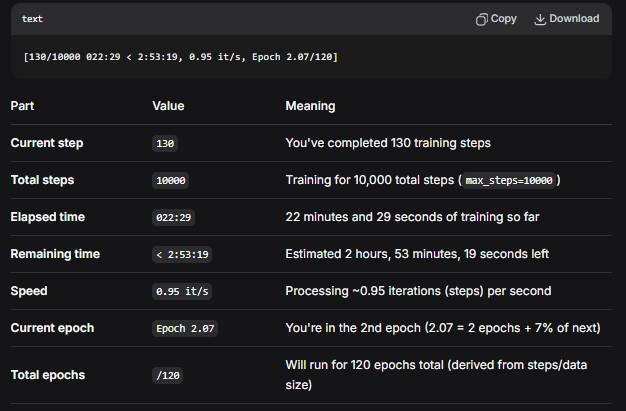

In [173]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 44, 'bos_token_id': 43}.


Step,Training Loss,Validation Loss


KeyboardInterrupt: 